# LHCb $D_s^+\to\pi^-\pi^+\pi^+$ — COW sWeights with an experimental log barrier

This example implements the nominal $D_s^+\to\pi^-\pi^+\pi^+$ amplitude model using the public Jax-PWA APIs. The particle ordering is $(\pi^-,\pi^+,\pi^+)$: `s12` and `s13` are the two opposite-sign $\pi^-\pi^+$ combinations and `s23` is the same-sign $\pi^+\pi^+$ combination.

The full candidate mass spectrum is first fitted with an **extended unbinned likelihood**, following Chapter 4 of LHCb-ANA-2022-011. The signal model is
$f_{CB}\,\mathrm{CrystalBall} + (1-f_{CB})\,\mathrm{Gaussian}$ with the original parameter relations
$\mu_G=\mu_{CB}+\mu_{\mathrm{offset}}$ and
$\sigma_G=\sigma_{CB}\,\sigma_{\mathrm{Ratio}}$; the combinatorial background is exponential. The fitted mass PDFs are then passed to the `sweights` package's stable `Cow` implementation to compute COW signal weights.

The Dalitz fit contains no explicit background histogram: it uses the COW-weighted objective plus a configurable squared-log barrier against very small signal densities at negative-weight events. The Dalitz variables remain the DTF/mass-constrained invariants so all candidates in the full mass-fit range share the nominal $D_s$ Dalitz boundary.

Reference amplitude model: LHCb, JHEP 07 (2023) 204, arXiv:2209.09840.

This is an experimental copy of `ds_pipipi_lhcb2023_goofit_real_data_fit_cow_sweights.ipynb`,
including its local settings at copy time. The mass selection and COW construction are unchanged.
The barrier changes the estimator and requires bias/coverage validation with toys or a full
mass-fit → COW → Dalitz bootstrap. After a valid fit, the notebook computes the **regularized fixed-weight sandwich**
covariance. It includes the barrier in both matrices, but excludes mass-fit/COW
estimation uncertainty and does not measure regularization bias. No full real-data fit has been pre-executed in this copy.


In [1]:
import gc
import warnings
from dataclasses import dataclass
from pathlib import Path
from types import MappingProxyType

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from sweights import Cow

from jaxpwa import (
    QMI,
    CrystalBall1D,
    DecayChannel,
    DecayModel,
    Exponential1D,
    FitSession,
    Gaussian1D,
    GooFitLegacyAngular,
    GounarisSakurai,
    Minimizer,
    Parameter,
    PhaseSpaceSample,
    plot_dalitz,
    RealImag,
    Resonance,
    WeightedUnbinnedNLL,
    dalitz_s13_limits,
    enable_x64,
    generate_toy,
    histogram_efficiency_from_root,
    read_root_tree,
)
from jaxpwa.likelihood.weighted import sandwich_covariance_from_score_outer
from jaxpwa.workflow import _install_minuit_covariance

enable_x64()
print('JAX backend:', jax.default_backend())
print('JAX devices:', jax.devices())



JAX backend: gpu
JAX devices: [CudaDevice(id=0)]


## 1. Input files, mass branch and Dalitz convention

Install the optional sPlot/COW dependency with `python -m pip install -e ".[splot]"`; the package already declares `splot = ["sweights"]` in `pyproject.toml`.

The ROOT branches are read in one call so the mass values and Dalitz coordinates stay event-by-event aligned. `MASS_TO_GEV` is explicit rather than inferred: keep `1e-3` for a mass branch stored in MeV and change it to `1.0` if the branch is already in GeV.


In [17]:
DATA_FILE = Path('/home/juan-leite/Work/data/DsPPP_FullData_AllSelectionCuts_Splot_FReweighted_MeanMVA.root')
DATA_TREE = 'DecayTree'

S12_BRANCH = 's12_pipi_DTF'
S13_BRANCH = 's13_pipi_DTF'
S23_BRANCH = 's23_pipi_DTF'
MASS_BRANCH = 'D_MM'  # change to the mass branch in the full-spectrum sample
BDTG_BRANCH = 'valBDT_mean'
BDTG_MIN = 0.65

MASS_TO_GEV = 1e-3    # use 1.0 if MASS_BRANCH is already in GeV

# Chapter 4 / original sPlot fit range: 1910--2030 MeV.
MASS_RANGE_GEV = (1.910, 2.030)

DATA_CUT = None
ENTRY_START, ENTRY_STOP = None, None

EFFICIENCY_FILE = Path('/home/juan-leite/Work/data/acc_hist_15_95_Smoothed_normalized.root')
EFFICIENCY_HIST = 'h_eff'

RUN_PREFIT_TOY_COMPARISON = True
TOY_SEED = 20230922
RUN_FIT = True
RANDOMIZE_START = True  # start the fit from a random point instead of published_start
RANDOMIZE_SEED = 20230922  # fixed seed reproduces the draw; None gives a fresh draw


# Experimental settings, not values tuned/validated on this dataset.
BARRIER_STRENGTH = 1.0     # lambda >= 0; zero recovers the original weighted Q
BARRIER_EPSILON = 1e-2    # penalize p/q < epsilon at negative-weight events
FIT_NCALL = 100_000
FIT_STRATEGY = 2
FIT_TOLERANCE = 1.0
FIT_VERBOSE = 3

# Optional, potentially expensive: independent fits from the SAME starting point.
RUN_BARRIER_SCAN = False
BARRIER_SCAN_SETTINGS = (
    (0.0, 1e-2),  # unregularized control; may fail to converge
    (0.3, 3e-3),
    (1.0, 3e-3),
    (0.3, 1e-2),
    (1.0, 1e-2),
    (3.0, 1e-2),
)

# Postfit covariance conditional on the observed COW weights and fixed lambda/epsilon.
COMPUTE_BARRIER_COVARIANCE = False

## 2. Published QMI S-wave starting point

The 50 knots below are the published central values around which the common DP starting point is randomized. `QMI(..., interpolation='linear')` linearly interpolates the magnitude and phase parameters in $s=m^2$.

In [3]:
QMI_KNOTS_GEV = np.array([
    0.280,0.390,0.470,0.546,0.623,0.698,0.766,0.819,0.865,0.900,
    0.925,0.942,0.955,0.964,0.972,0.978,0.983,0.990,1.001,1.023,
    1.051,1.083,1.116,1.149,1.179,1.205,1.227,1.245,1.261,1.276,
    1.289,1.302,1.314,1.326,1.338,1.351,1.363,1.375,1.387,1.399,
    1.411,1.424,1.437,1.450,1.465,1.484,1.511,1.554,1.613,1.823,
])
QMI_MAGNITUDE_PAPER = np.array([
    4.54,4.05,4.10,4.41,4.69,4.691,4.994,5.43,6.405,8.096,
    10.624,13.47,16.56,19.45,22.15,24.62,26.95,20.89,13.695,10.995,
    9.593,8.731,7.606,6.961,6.515,6.506,6.264,6.125,6.081,6.071,
    5.912,5.893,5.901,6.031,5.904,6.086,6.181,6.185,6.60,6.63,
    6.90,7.14,7.22,7.56,7.33,7.13,5.009,2.456,2.31,3.75,
])
QMI_PHASE_DEG_PAPER = np.array([
    176.8,152.8,147.6,146.4,149.6,157.4,169.5,-172.8,-152.0,-133.0,
    -116.5,-103.0,-88.8,-74.9,-59.5,-56.7,-21.8,-9.8,5.45,11.28,
    21.57,36.27,48.02,54.42,63.46,63.47,72.45,72.80,77.2,82.2,
    86.1,88.8,93.2,93.8,98.7,103.3,105.7,110.4,114.5,119.7,
    126.5,132.3,142.03,153.74,166.50,-172.15,-136.8,-126.8,-99.5,3.0,
])
QMI_PHASE_RAD_START = np.unwrap(np.deg2rad(QMI_PHASE_DEG_PAPER))
assert len(QMI_KNOTS_GEV) == len(QMI_MAGNITUDE_PAPER) == len(QMI_PHASE_RAD_START) == 50

## 3. Build the amplitude model

The $f_2(1270)$ coefficient is the fixed reference. The QMI contributes 100 floating dynamics parameters and the five other resonances contribute five complex coefficients, for 110 free parameters.

In [4]:
def polar_coefficient(name, magnitude, phase_deg, *, fixed=False):
    phase = np.deg2rad(phase_deg)
    x = float(magnitude * np.cos(phase))
    y = float(magnitude * np.sin(phase))
    if fixed:
        return RealImag(x, y)
    return RealImag(
        Parameter.coefficient(f'{name}.x', x, owner=name, step=0.01),
        Parameter.coefficient(f'{name}.y', y, owner=name, step=0.01),
    )

S_OWNER = 'pipi_S_qmi'
s_magnitudes = tuple(
    Parameter.dynamics(f'S.mag_{i:02d}', float(v), owner=S_OWNER, bounds=(0.0, None), step=max(0.02, 0.01*float(v)))
    for i, v in enumerate(QMI_MAGNITUDE_PAPER)
)
s_phases = tuple(
    Parameter.dynamics(f'S.phase_{i:02d}', float(v), owner=S_OWNER, step=np.deg2rad(1.0))
    for i, v in enumerate(QMI_PHASE_RAD_START)
)
qmi_s_wave = QMI(tuple(QMI_KNOTS_GEV), s_magnitudes, s_phases, interpolation='linear')

coeff = {
    'rho770': polar_coefficient('rho770', 0.1201, 79.4),
    'omega782': polar_coefficient('omega782', 0.04001, -109.9),
    'rho1450': polar_coefficient('rho1450', 1.277, -115.2),
    'rho1700': polar_coefficient('rho1700', 0.873, -60.9),
    'f2_1270': polar_coefficient('f2_1270', 1.0, 0.0, fixed=True),
    'f2p_1525': polar_coefficient('f2p_1525', 0.1098, 178.1),
}

channel = DecayChannel('D_s+', ('pi-', 'pi+', 'pi+'))
angular = GooFitLegacyAngular()
bachelor_momentum_frame="parent"
R_D, R_R = 5.0, 1.5

def resonance(name, coefficient, mass, width, spin, *, lineshape=None):
    kwargs = {} if lineshape is None else {'lineshape': lineshape}
    return Resonance(
        name, (0, 1), coefficient, mass=mass, width=width, spin=spin,
        angular=angular, resonance_radius=R_R, parent_radius=R_D, bachelor_momentum_frame=bachelor_momentum_frame, **kwargs
    )

model = DecayModel(
    channel,
    [
        Resonance(S_OWNER, (0, 1), RealImag(1.0, 0.0), mass=1.0, width=0.0, spin=0,
                  lineshape=qmi_s_wave, angular=angular, resonance_radius=R_R, parent_radius=R_D, bachelor_momentum_frame=bachelor_momentum_frame),
        resonance('rho770', coeff['rho770'], 0.77526, 0.1491, 1, lineshape=GounarisSakurai()),
        resonance('omega782', coeff['omega782'], 0.78265, 0.00849, 1),
        resonance('rho1450', coeff['rho1450'], 1.465, 0.400, 1),
        resonance('rho1700', coeff['rho1700'], 1.720, 0.250, 1),
        resonance('f2_1270', coeff['f2_1270'], 1.2755, 0.1867, 2),
        resonance('f2p_1525', coeff['f2p_1525'], 1.5174, 0.086, 2),
    ],
    normalize_components=False,
    # normalization_method="square-dalitz",
    # normalization_resolution=300,
    # normalization_pair=(1,2),
)

print('components:', [c.name for c in model.components])
print('free model parameters:', sum(not p.fixed for p in model.parameters))
assert sum(not p.fixed for p in model.parameters) == 110

components: ['pipi_S_qmi', 'rho770', 'omega782', 'rho1450', 'rho1700', 'f2_1270', 'f2p_1525']
free model parameters: 110


## 4. Read data, apply the final BDT cut, and require physical Dalitz support

The final MVA requirement, `valBDT_mean > 0.65`, is applied immediately after loading the ROOT tree. The 1910--2030 MeV mass range is then selected, followed by the exact physical $D_s^+\to\pi^-\pi^+\pi^+$ Dalitz support requirement.

This ordering is deliberate: **the extended mass fit, its signal/background yields, the COW construction, and the weighted amplitude fit all use exactly the same event sample**.

Before the physical-support cut, the stored DTF invariants are checked against

$$

s_{12}+s_{13}+s_{23}
=
m_{D_s}^2+m_1^2+m_2^2+m_3^2.

$$

The physical-domain test uses $s_{12}$ and the exact allowed $s_{13}$ interval at fixed $s_{12}$. For accepted events, $s_{23}$ is reconstructed from the closure relation so the amplitude model receives an exactly self-consistent invariant triplet.

No Dalitz-background histogram is loaded. Background subtraction in the amplitude fit is entirely carried by the COW signal weights derived from the mass fit below.


In [5]:
arrays = read_root_tree(
    DATA_FILE,
    DATA_TREE,
    {
        's12': S12_BRANCH,
        's13': S13_BRANCH,
        's23': S23_BRANCH,
        'mass': MASS_BRANCH,
        'bdtg': BDTG_BRANCH,
    },
    cut=DATA_CUT,
    entry_start=ENTRY_START,
    entry_stop=ENTRY_STOP,
    library='np',
)

mass_all = np.asarray(arrays['mass'], dtype=float) * MASS_TO_GEV
bdtg_all = np.asarray(arrays['bdtg'], dtype=float)
s12_all = np.asarray(arrays['s12'], dtype=float)
s13_all = np.asarray(arrays['s13'], dtype=float)
s23_all = np.asarray(arrays['s23'], dtype=float)

bdtg_mask = np.isfinite(bdtg_all) & (bdtg_all > BDTG_MIN)
mass_range_mask = (
    bdtg_mask
    & np.isfinite(mass_all)
    & (mass_all >= MASS_RANGE_GEV[0])
    & (mass_all <= MASS_RANGE_GEV[1])
)

# Inspect the stored DTF invariant closure before applying the physical-Dalitz cut.
M = float(channel.parent_mass)
m1, m2, m3 = map(float, channel.daughter_masses)
dalitz_constant = M**2 + m1**2 + m2**2 + m3**2

candidate_indices = np.flatnonzero(mass_range_mask)
s12_candidate = s12_all[candidate_indices]
s13_candidate = s13_all[candidate_indices]
s23_candidate = s23_all[candidate_indices]

closure = s12_candidate + s13_candidate + s23_candidate - dalitz_constant
finite_closure = np.isfinite(closure)
abs_closure = np.abs(closure[finite_closure])

print('DTF closure diagnostic before physical-Dalitz selection:')
if abs_closure.size:
    print(f'  median(closure)       = {np.median(closure[finite_closure]): .6e} GeV^2')
    print(f'  RMS(closure)          = {np.sqrt(np.mean(closure[finite_closure]**2)): .6e} GeV^2')
    print(f'  99.9% |closure|       = {np.quantile(abs_closure, 0.999): .6e} GeV^2')
    print(f'  max |closure|         = {abs_closure.max(): .6e} GeV^2')
else:
    print('  no finite closure values')

s12_min = (m1 + m2)**2
s12_max = (M - m3)**2

s13_low_jax, s13_high_jax = dalitz_s13_limits(
    jnp.asarray(s12_candidate),
    mother_mass=M,
    masses=(m1, m2, m3),
)
s13_low = np.asarray(s13_low_jax)
s13_high = np.asarray(s13_high_jax)

finite_dalitz = (
    np.isfinite(s12_candidate)
    & np.isfinite(s13_candidate)
    & np.isfinite(s23_candidate)
)
physical_s12 = (s12_candidate >= s12_min) & (s12_candidate <= s12_max)
physical_s13 = (s13_candidate >= s13_low) & (s13_candidate <= s13_high)

s23_reconstructed_candidate = dalitz_constant - s12_candidate - s13_candidate
s23_min = (m2 + m3)**2
s23_max = (M - m1)**2
physical_s23 = (
    np.isfinite(s23_reconstructed_candidate)
    & (s23_reconstructed_candidate >= s23_min)
    & (s23_reconstructed_candidate <= s23_max)
)

physical_candidate_mask = (
    finite_dalitz
    & physical_s12
    & physical_s13
    & physical_s23
)

selected_indices = candidate_indices[physical_candidate_mask]
n_mass_range = candidate_indices.size
n_physical = selected_indices.size
n_rejected = n_mass_range - n_physical

mass = mass_all[selected_indices]
s12 = s12_all[selected_indices]
s13 = s13_all[selected_indices]
s23 = dalitz_constant - s12 - s13

data = PhaseSpaceSample(
    s12=jnp.asarray(s12),
    s13=jnp.asarray(s13),
    s23=jnp.asarray(s23),
    weights=jnp.ones(n_physical, dtype=jnp.float64),
)

efficiency = histogram_efficiency_from_root(
    EFFICIENCY_FILE,
    EFFICIENCY_HIST,
    x_variable='s12',
    y_variable='s13',
)

print()
print(f'Loaded {len(mass_all):,} candidates')
print(
    f'After {BDTG_BRANCH} > {BDTG_MIN}: '
    f'{np.count_nonzero(bdtg_mask):,} candidates'
)
print(
    f'After BDT + {MASS_RANGE_GEV[0]:.3f} < m < {MASS_RANGE_GEV[1]:.3f} GeV: '
    f'{n_mass_range:,} candidates'
)
print(
    f'Inside physical Dalitz support: {n_physical:,} candidates'
)
print(
    f'Rejected as non-physical: {n_rejected:,} '
    f'({100.0*n_rejected/max(n_mass_range, 1):.4f}%)'
)
print(f'  outside global s12     = {np.count_nonzero(~physical_s12):,}')
print(f'  outside s13(s12) band  = {np.count_nonzero(physical_s12 & ~physical_s13):,}')
print(f'  outside reconstructed s23 range = {np.count_nonzero(~physical_s23):,}')

bad_candidate_indices = np.flatnonzero(~physical_candidate_mask)
if bad_candidate_indices.size:
    print()
    print('First rejected candidates:')
    for local_idx in bad_candidate_indices[:10]:
        original_idx = candidate_indices[local_idx]
        print(
            f'  i={original_idx:7d}  m={mass_all[original_idx]:.6f}  '
            f's12={s12_candidate[local_idx]:.6f}  '
            f's13={s13_candidate[local_idx]:.6f}  '
            f's23(stored)={s23_candidate[local_idx]:.6f}  '
            f'closure={closure[local_idx]:+.3e}'
        )

selected_closure = (
    np.asarray(data.s12)
    + np.asarray(data.s13)
    + np.asarray(data.s23)
    - dalitz_constant
)
print(f'max reconstructed |closure| = {np.max(np.abs(selected_closure)):.3e} GeV^2')

for name in ('s12', 's13', 's23'):
    values = np.asarray(getattr(data, name))
    print(f'{name}: [{values.min():.6g}, {values.max():.6g}] GeV^2')

# Free the raw/intermediate read-and-selection arrays: only `mass`, `s12`,
# `s13`, `s23`, `data` and `efficiency` are needed from here on. This also
# drops `s13_low_jax`/`s13_high_jax`, the only two JAX (GPU) device arrays
# this cell produced beyond `data` itself.
del (
    arrays, mass_all, bdtg_all, s12_all, s13_all, s23_all,
    bdtg_mask, mass_range_mask, candidate_indices,
    s12_candidate, s13_candidate, s23_candidate,
    closure, finite_closure, abs_closure,
    s13_low_jax, s13_high_jax, s13_low, s13_high,
    finite_dalitz, physical_s12, physical_s13,
    s23_reconstructed_candidate, physical_s23, physical_candidate_mask,
    selected_indices, bad_candidate_indices, selected_closure,
)
gc.collect()


DTF closure diagnostic before physical-Dalitz selection:
  median(closure)       =  5.509823e-04 GeV^2
  RMS(closure)          =  6.832844e-03 GeV^2
  99.9% |closure|       =  6.442568e-02 GeV^2
  max |closure|         =  1.053484e+00 GeV^2

Loaded 8,907,420 candidates
After valBDT_mean > 0.65: 900,268 candidates
After BDT + 1.910 < m < 2.030 GeV: 900,268 candidates
Inside physical Dalitz support: 899,831 candidates
Rejected as non-physical: 437 (0.0485%)
  outside global s12     = 0
  outside s13(s12) band  = 437
  outside reconstructed s23 range = 109

First rejected candidates:
  i=  25325  m=1.962576  s12=2.365538  s13=1.485258  s23(stored)=0.082597  closure=+5.510e-04
  i=  49293  m=1.978248  s12=0.971924  s13=2.856676  s23(stored)=0.104792  closure=+5.510e-04
  i= 123821  m=1.956467  s12=1.900937  s13=1.954519  s23(stored)=0.077936  closure=+5.510e-04
  i= 133820  m=1.960861  s12=2.892030  s13=0.933907  s23(stored)=0.107456  closure=+5.510e-04
  i= 214750  m=1.973898  s12=1.85159

3234

### Raw $D_s^+\to\pi^-\pi^+\pi^+$ mass spectrum before the fit

Sanity check on the **same sample that will be used throughout the rest of the notebook**: `valBDT_mean > 0.65`, 1910--2030 MeV, and inside the physical $D_s$ Dalitz support.


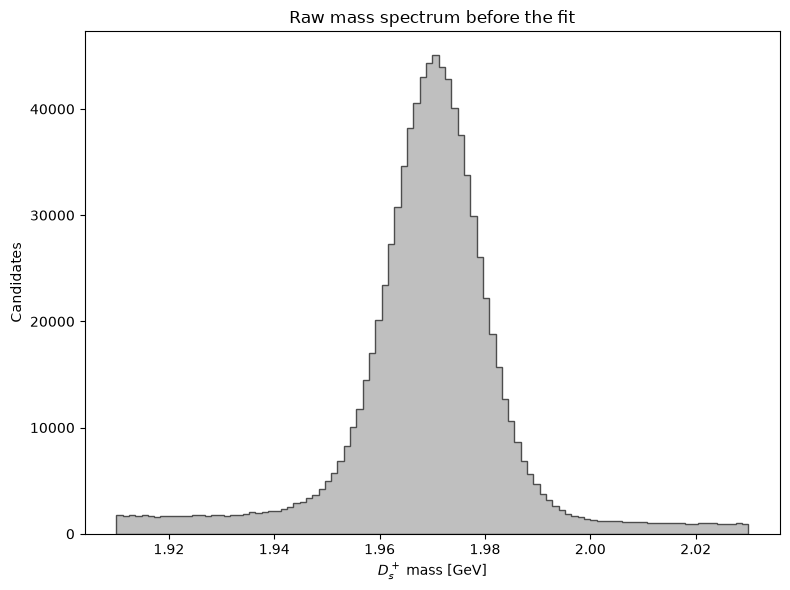

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(mass, bins=100, range=MASS_RANGE_GEV, histtype='stepfilled', color='0.75', edgecolor='0.3')
ax.set_xlabel(r'$D_s^+$ mass [GeV]')
ax.set_ylabel('Candidates')
ax.set_title('Raw mass spectrum before the fit')
fig.tight_layout()
plt.show()

## 5. Extended mass fit — Chapter 4 model

The mass fit follows the analysis-note parameterisation:

$$

P_s(m)=f_{CB}\,CB(m;\alpha,n,\mu_{CB},\sigma_{CB})
+(1-f_{CB})\,G(m;\mu_G,\sigma_G),

$$

with

$$

\mu_G=\mu_{CB}+\mu_{\mathrm{offset}},
\qquad
\sigma_G=\sigma_{CB}\,\sigma_{\mathrm{Ratio}},

$$

and an exponential background. All signal-shape parameters, the exponential slope, and the two extended yields are free. The numerical starting values below reproduce the central values from Table 11 where available; the background slope is only a numerical seed because it is not quoted in that table.


In [7]:
MASS_LOW, MASS_HIGH = MASS_RANGE_GEV


def signal_mass_pdf(x, alpha, n, mu_cb, sigma_cb, mu_offset, sigma_ratio, f_cb):
    mu_g = mu_cb + mu_offset
    sigma_g = sigma_cb * sigma_ratio
    cb = CrystalBall1D(
        mean=mu_cb, sigma=sigma_cb, alpha=alpha, n=n, low=MASS_LOW, high=MASS_HIGH
    )
    gauss = Gaussian1D(mean=mu_g, sigma=sigma_g, low=MASS_LOW, high=MASS_HIGH)
    return f_cb * cb(x) + (1.0 - f_cb) * gauss(x)


def background_mass_pdf(x, slope):
    return Exponential1D(slope=slope, low=MASS_LOW, high=MASS_HIGH)(x)


# JAX-native extended unbinned NLL, fitted through jaxpwa's own `Minimizer`
# instead of `iminuit.cost.ExtendedUnbinnedNLL` over `scipy.stats.crystalball`:
# that combination has no analytic gradient, so Minuit falls back to
# finite-differencing all 10 parameters through a pure-Python/scipy PDF
# evaluated on ~900k events per call. Here the whole density is JAX, so
# `Minimizer` JIT-compiles one value-and-gradient program and gets exact
# gradients from `jax.grad` instead.
mass_jax = jnp.asarray(mass)


def mass_nll(parameters):
    nsig = parameters['nsig']
    nbkg = parameters['nbkg']
    signal = signal_mass_pdf(
        mass_jax,
        parameters['alpha'],
        parameters['n'],
        parameters['mu_cb'],
        parameters['sigma_cb'],
        parameters['mu_offset'],
        parameters['sigma_ratio'],
        parameters['f_cb'],
    )
    background = background_mass_pdf(mass_jax, parameters['slope'])
    density = nsig * signal + nbkg * background
    return (nsig + nbkg) - jnp.sum(jnp.log(density))


# Table 11 central values, converted from MeV to GeV where appropriate.
mass_parameters_config = [
    Parameter('nsig', 771_130.0, bounds=(0.0, None)),
    Parameter('nbkg', 129_288.0, bounds=(0.0, None)),
    Parameter('alpha', 1.681, bounds=(0.05, 10.0)),
    Parameter('n', 11.0, bounds=(1.01, 100.0)),
    Parameter('mu_cb', 1.96978, bounds=MASS_RANGE_GEV),
    Parameter('sigma_cb', 0.01039, bounds=(5e-4, 0.05)),
    Parameter('mu_offset', 0.00098, bounds=(-0.02, 0.02)),
    Parameter('sigma_ratio', 0.6666, bounds=(0.05, 5.0)),
    Parameter('f_cb', 0.52, bounds=(0.0, 1.0)),
    Parameter('slope', -5.0, bounds=(-100.0, 100.0)),
]

mass_minimizer = Minimizer(mass_nll, mass_parameters_config)
mass_fit = mass_minimizer.fit()
print(mass_fit)

# Only the fitted `mass_fit` result is needed downstream: drop the
# JIT-compiled objective and the device array it closes over.
del mass_nll, mass_jax, mass_minimizer
gc.collect()


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -1.406e+07                 │        Nfcn = 661, Ngrad = 8         │
│ EDM = 2.15e-08 (Goal: 1e-07)     │            time = 8.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬─────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────

100

mu_G       = 1970.741 MeV
sigma_G    = 6.978 MeV
sigma_eff  = 8.927 MeV
legacy signal region (mu_CB +/- 2 sigma_eff): [1951.9, 1987.6] MeV


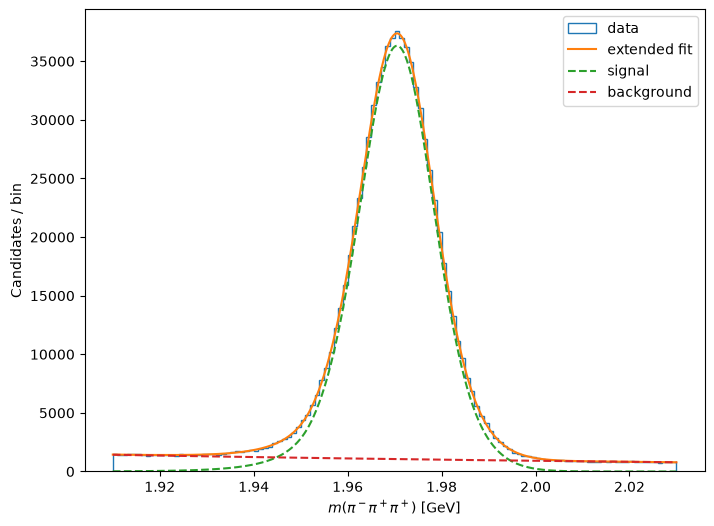

In [8]:
mass_parameters = mass_fit.values.to_dict()

mu_g_fit = mass_parameters['mu_cb'] + mass_parameters['mu_offset']
sigma_g_fit = mass_parameters['sigma_cb'] * mass_parameters['sigma_ratio']
sigma_eff_fit = np.sqrt(
    mass_parameters['f_cb'] * mass_parameters['sigma_cb']**2
    + (1.0 - mass_parameters['f_cb']) * sigma_g_fit**2
)

print(f'mu_G       = {1e3 * mu_g_fit:.3f} MeV')
print(f'sigma_G    = {1e3 * sigma_g_fit:.3f} MeV')
print(f'sigma_eff  = {1e3 * sigma_eff_fit:.3f} MeV')
print(
    'legacy signal region (mu_CB +/- 2 sigma_eff): '
    f'[{1e3 * (mass_parameters["mu_cb"] - 2 * sigma_eff_fit):.1f}, '
    f'{1e3 * (mass_parameters["mu_cb"] + 2 * sigma_eff_fit):.1f}] MeV'
)

x_mass = np.linspace(MASS_LOW, MASS_HIGH, 1000)
signal_curve = signal_mass_pdf(
    x_mass,
    mass_parameters['alpha'],
    mass_parameters['n'],
    mass_parameters['mu_cb'],
    mass_parameters['sigma_cb'],
    mass_parameters['mu_offset'],
    mass_parameters['sigma_ratio'],
    mass_parameters['f_cb'],
)
background_curve = background_mass_pdf(x_mass, mass_parameters['slope'])

fig, ax = plt.subplots(figsize=(8, 6))
counts, edges, _ = ax.hist(
    mass,
    bins=120,
    range=MASS_RANGE_GEV,
    histtype='step',
    label='data',
)
bin_width = edges[1] - edges[0]
ax.plot(
    x_mass,
    bin_width * (
        mass_parameters['nsig'] * signal_curve
        + mass_parameters['nbkg'] * background_curve
    ),
    label='extended fit',
)
ax.plot(
    x_mass,
    bin_width * mass_parameters['nsig'] * signal_curve,
    '--',
    label='signal',
)
ax.plot(
    x_mass,
    bin_width * mass_parameters['nbkg'] * background_curve,
    '--',
    label='background',
)
ax.set(xlabel=r'$m(\pi^-\pi^+\pi^+)$ [GeV]', ylabel='Candidates / bin')
ax.legend()
plt.show()


## 6. COW signal weights

The fitted signal and background shapes are frozen and passed to `sweights.Cow`. The extended mass fit above was performed **after** the BDT, mass-range, and physical-Dalitz selections, so its $N_s$, $N_b$, fitted signal fraction, COW weights, and subsequent weighted Dalitz likelihood all refer to the same candidate sample.

We choose the fitted total mass density as the COW variance function,

$$

I(m)=f_s\,g_s(m)+(1-f_s)\,g_b(m),

$$

which gives the minimum-variance two-component COW/sWeight construction for the fitted mass model. The resulting signal weights may be negative.

The COW weights are **not** stored in `PhaseSpaceSample.weights`: those weights have integration/proposal semantics in Jax-PWA. They are passed separately to `WeightedUnbinnedNLL`.


sum signal COW weights     = 770,725.9
fitted signal yield         = 770,726.0
sum background COW weights = 129,105.1
fitted background yield     = 129,105.1
min/max signal weight       = -0.807, 1.08
negative signal weights     = 80,833
sum w^2                     = 874,920.6
N_eff = 678,939.8


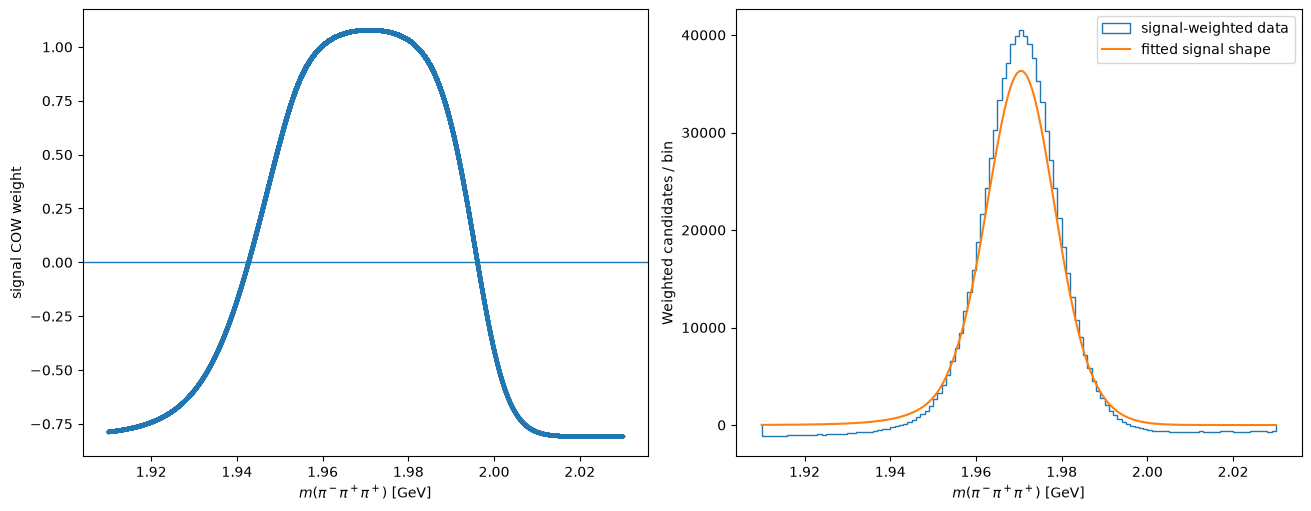

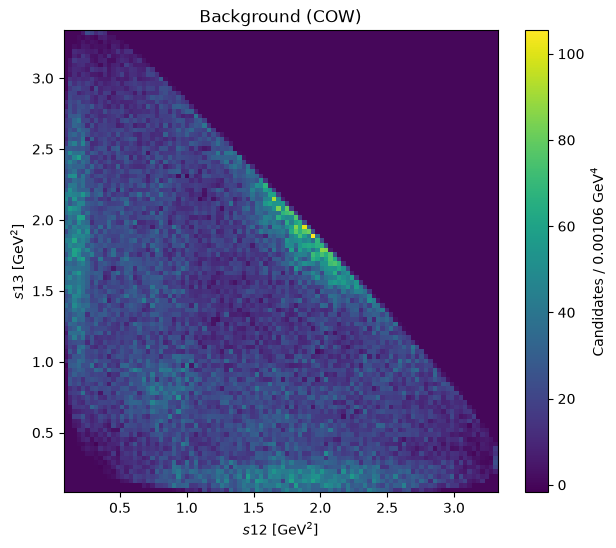

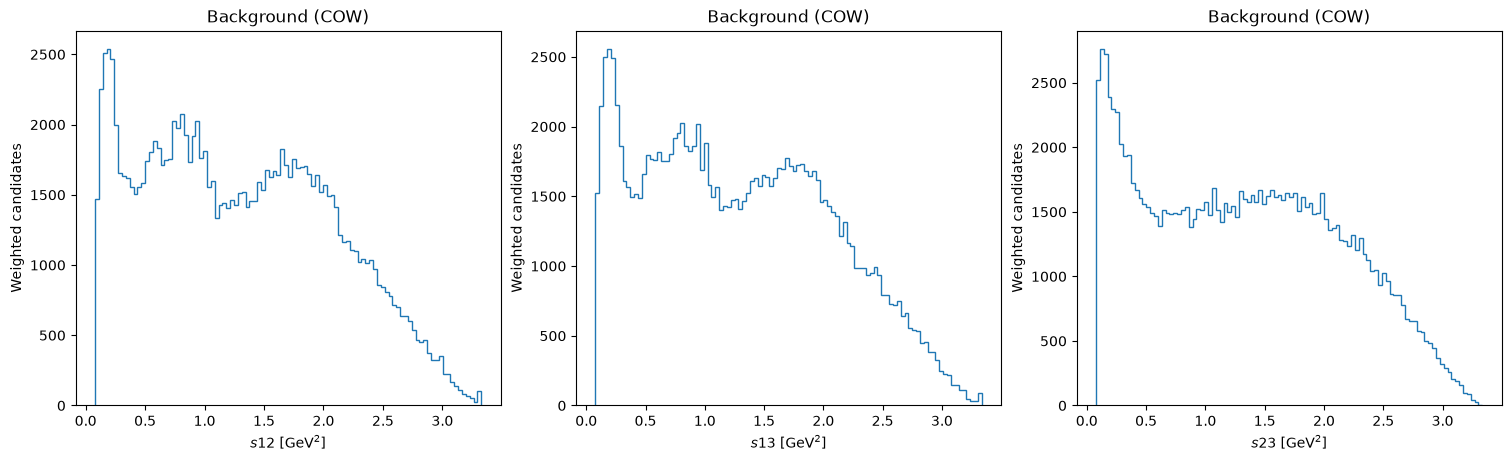

14678

In [9]:
def fitted_signal_mass_pdf(x):
    return signal_mass_pdf(
        x,
        mass_parameters['alpha'],
        mass_parameters['n'],
        mass_parameters['mu_cb'],
        mass_parameters['sigma_cb'],
        mass_parameters['mu_offset'],
        mass_parameters['sigma_ratio'],
        mass_parameters['f_cb'],
    )


def fitted_background_mass_pdf(x):
    return background_mass_pdf(x, mass_parameters['slope'])


fitted_signal_fraction = (
    mass_parameters['nsig']
    / (mass_parameters['nsig'] + mass_parameters['nbkg'])
)


def fitted_total_mass_pdf(x):
    return (
        fitted_signal_fraction * fitted_signal_mass_pdf(x)
        + (1.0 - fitted_signal_fraction) * fitted_background_mass_pdf(x)
    )


cow = Cow(
    MASS_RANGE_GEV,
    fitted_signal_mass_pdf,
    fitted_background_mass_pdf,
    Im=fitted_total_mass_pdf,
    renorm=False,
)

signal_weights = np.asarray(cow(mass), dtype=float)
background_weights = np.asarray(cow(mass, idx=1), dtype=float)

print(f'sum signal COW weights     = {signal_weights.sum():,.1f}')
print(f'fitted signal yield         = {mass_parameters["nsig"]:,.1f}')
print(f'sum background COW weights = {background_weights.sum():,.1f}')
print(f'fitted background yield     = {mass_parameters["nbkg"]:,.1f}')
print(f'min/max signal weight       = {signal_weights.min():.4g}, {signal_weights.max():.4g}')
print(f'negative signal weights     = {np.count_nonzero(signal_weights < 0):,}')
print(f'sum w^2                     = {np.sum(signal_weights**2):,.1f}')
print(
    'N_eff =',
    f'{signal_weights.sum()**2 / np.sum(signal_weights**2):,.1f}',
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
axes[0].scatter(mass, signal_weights, s=2, alpha=0.25)
axes[0].axhline(0.0, linewidth=1)
axes[0].set(
    xlabel=r'$m(\pi^-\pi^+\pi^+)$ [GeV]',
    ylabel='signal COW weight',
)
axes[1].hist(
    mass,
    bins=120,
    range=MASS_RANGE_GEV,
    weights=signal_weights,
    histtype='step',
    label='signal-weighted data',
)
axes[1].plot(
    x_mass,
    bin_width * signal_weights.sum() * fitted_signal_mass_pdf(x_mass),
    label='fitted signal shape',
)
axes[1].set(
    xlabel=r'$m(\pi^-\pi^+\pi^+)$ [GeV]',
    ylabel='Weighted candidates / bin',
)
axes[1].legend()
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
plot_dalitz(
    data, x='s12', y='s13', weights=background_weights,
    ax=ax, title='Background (COW)',
)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
for ax, variable in zip(axes, ('s12', 's13', 's23'), strict=True):
    observed = np.asarray(getattr(data, variable))
    ax.hist(
        observed,
        bins=100,
        weights=background_weights,
        histtype='step',
    )
    ax.set(
        xlabel='$' + variable + '$ [GeV$^2$]',
        ylabel='Weighted candidates',
        title='Background (COW)',
    )
plt.show()

# `cow` and `background_weights` are not used again; `signal_weights` is.
del cow, background_weights
gc.collect()


### One shared random starting point for all DP fits

Run the next cell once before the fit/scan cells. It draws every **free** parameter
and stores the result in the read-only `dp_start` mapping. Each DP fit receives a
fresh dictionary copy of those same values. Neither the nominal fit nor the scan
draws another start or uses a previous fitted endpoint as its start.

`Minimizer.random_start` draws a Gaussian around each parameter's declared value,
with standard deviation `10 * step` when a step is available, and clips one-sided
bounds. Parameters with two finite bounds are drawn uniformly within them. Here,
the QMI phases have a 1-degree step, so their random shifts have a 10-degree
standard deviation. Fixed parameters stay fixed. `dp_start_comparison` records
the published value, draw and shift for all 110 free parameters.

A fixed `RANDOMIZE_SEED` reproduces the same draw when this cell is rerun. To choose
a different common start, change the seed (or use `None`), rerun this cell, and then
rerun the fit and scan cells. `RANDOMIZE_START=False` uses the published start.
The prefit projections below use this same `dp_start`, including the randomized
values when randomization is enabled.


In [10]:
published_start = {p.name: float(p.value) for p in model.parameters if not p.fixed}

session = FitSession(
    model,
    data,
    efficiency=efficiency,
)

weighted_nll = WeightedUnbinnedNLL(
    session._cached_signal_logpdf,
    data.as_dict(),
    jnp.asarray(signal_weights),
)

# Execute this cell once to choose the common DP starting point.
# Only rerunning THIS cell generates a draw; fit/scan cells just copy dp_start.
if RANDOMIZE_START:
    drawn_values = session.minimizer().random_start(seed=RANDOMIZE_SEED)
else:
    drawn_values = dict(published_start)

# Prevent an accidental in-place update from replacing the common starting point.
dp_start = MappingProxyType(dict(drawn_values))
del drawn_values
free_parameters = tuple(p for p in session.parameters if not p.fixed)
assert set(dp_start) == {p.name for p in free_parameters}
dp_start_comparison = tuple(
    (p.name, float(p.value), dp_start[p.name], dp_start[p.name] - float(p.value))
    for p in free_parameters
)
changed_parameters = sum(delta != 0.0 for _, _, _, delta in dp_start_comparison)
print(f'Common DP start: randomized={RANDOMIZE_START}, seed={RANDOMIZE_SEED}')
print(f'Changed free parameters: {changed_parameters}/{len(free_parameters)}')
print('First 10 parameters (full table: dp_start_comparison):')
print(f'{"parameter":24s} {"published":>12s} {"DP start":>12s} {"shift":>12s}')
for name, nominal, initial, delta in dp_start_comparison[:10]:
    print(f'{name:24s} {nominal:12.6g} {initial:12.6g} {delta:12.6g}')


INFO Jax-PWA normalization: narrow resonance band(s) detected (m12: m0=0.782650 GeV, Gamma=8.490 MeV; m13: m0=0.782650 GeV, Gamma=8.490 MeV); using Square-Dalitz coordinates internally because m12 is diagonal in the conventional m13-m23 plane. Adaptive refinement is applied only along the mass axis m': 1296 m' nodes x 1000 theta' nodes (1,296,000 points).
INFO Jax-PWA normalization: floating component(s) ('pipi_S_qmi',) use order-dependent prepared state (e.g. QMI's sort order/interval boundaries), so the effective normalization chunk size is capped at dynamics_microbatch_size=20000 instead of the requested normalization_chunk_size=100000; see 'normalization_chunk_size is silently capped by dynamics_microbatch_size...' in docs/performance.md.
Common DP start: randomized=True, seed=20230922
Changed free parameters: 110/110
First 10 parameters (full table: dp_start_comparison):
parameter                   published     DP start        shift
S.mag_00                         4.54      4.78

## 7. Projections at the common DP starting point

Before fitting, compare the COW-weighted data with a signal-only toy generated at
exactly the shared `dp_start`, with the same efficiency. The three projections
are `s12`, `s13` and `s23`. Their histogram uncertainties are $\sqrt{\sum w_i^2}$.
The toy histograms are scaled to $\sum_i w_i$ and have finite toy statistics.

`RUN_PREFIT_TOY_COMPARISON=True` enables these plots. Reexecuting this plotting
cell does not redraw the starting parameters. If you change the common start,
rerun this cell and the fit/scan cells to keep the comparison consistent.


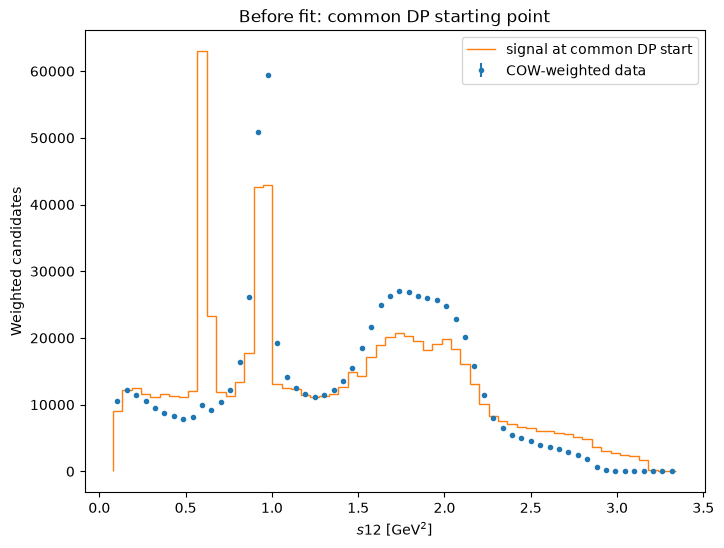

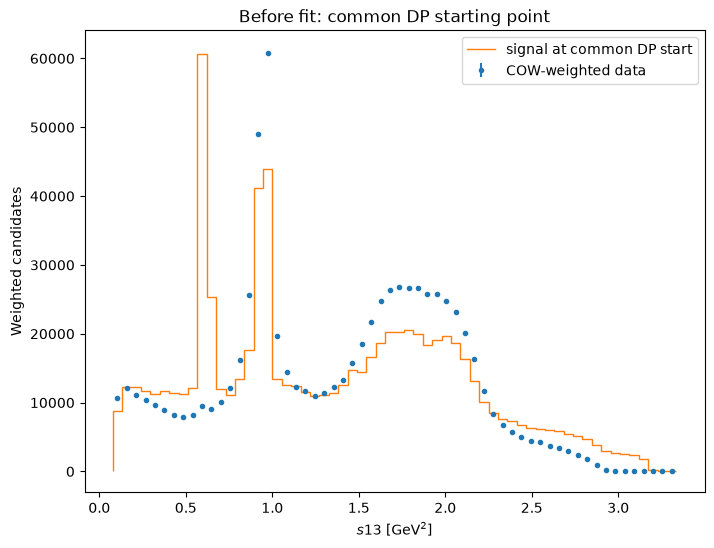

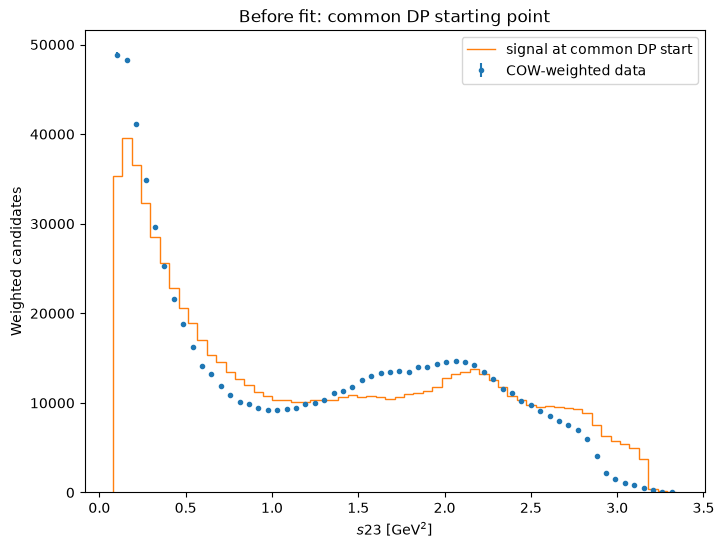

In [11]:
def plot_weighted_projection_comparison(variable, generated, bins=60):
    observed = np.asarray(getattr(data, variable))
    generated_values = np.asarray(getattr(generated, variable))
    edges = np.linspace(
        min(observed.min(), generated_values.min()),
        max(observed.max(), generated_values.max()),
        bins + 1,
    )

    weighted_counts, _ = np.histogram(
        observed,
        bins=edges,
        weights=signal_weights,
    )
    weighted_variance, _ = np.histogram(
        observed,
        bins=edges,
        weights=signal_weights**2,
    )
    generated_counts, _ = np.histogram(generated_values, bins=edges)
    generated_counts = (
        generated_counts
        * signal_weights.sum()
        / max(generated_counts.sum(), 1)
    )

    centers = 0.5 * (edges[:-1] + edges[1:])
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.errorbar(
        centers,
        weighted_counts,
        yerr=np.sqrt(weighted_variance),
        fmt='o',
        markersize=3,
        label='COW-weighted data',
    )
    ax.stairs(generated_counts, edges, label='signal at common DP start')
    ax.set(
        xlabel='$' + variable + '$ [GeV$^2$]',
        ylabel='Weighted candidates',
        title='Before fit: common DP starting point',
    )
    ax.legend()
    plt.show()


if RUN_PREFIT_TOY_COMPARISON:
    prefit_toy = generate_toy(
        model,
        max(1, int(round(signal_weights.sum()))),
        parameters=dict(dp_start),
        efficiency=efficiency,
        seed=TOY_SEED,
    )

    for variable in ('s12', 's13', 's23'):
        plot_weighted_projection_comparison(variable, prefit_toy)

    # `prefit_toy` is a large GPU-resident toy sample used only for the
    # plots above; nothing later in the notebook reads it.
    del prefit_toy
    gc.collect()


## 8. Experimental weighted fit with a squared-log barrier

We minimize

$$

Q_{\rm reg}(\theta)=-\sum_i w_i\log p_i(\theta)
+\lambda\sum_{w_i<0}|w_i|
\left[\max\left(0,\log\frac{\varepsilon q_i}{p_i(\theta)}\right)\right]^2.

$$

The fixed reference is a constant phase-space intensity multiplied by the same acceptance:

$$

q(x)=\frac{a(x)}{\int a(x)\,d\Phi},\qquad
\int a\,d\Phi=\operatorname{mean}(w_{\rm norm}\,a_{\rm norm}).

$$

It is normalized in the same integration measure as the signal PDF and is independent of
the starting amplitudes and fit parameters. The ratio removes units and the common
event acceptance. Zero/non-finite event acceptance is rejected before fitting.
The COW weights remain separate from the integration weights.

`BARRIER_EPSILON` sets the threshold in `p/q`; `BARRIER_STRENGTH` sets lambda.
Only negative-weight events below that threshold contribute. The penalty grows
quadratically in `log(p/q)` and eventually dominates the negative event's linear
logarithmic divergence. It leaves the PDF and normalization unchanged, but changes
the estimating equation. It can distort genuine interference minima. The defaults
are exploratory, not a claim of negligible bias or optimal regularization.

The implementation evaluates the prepared signal log-PDF **once per objective call**
and reuses it for both terms. It does not floor the density. For lambda > 0,
non-finite log-PDF proposals return +infinity rather than forming `-inf + inf`;
start from a finite point. This cannot guarantee that Minuit recovers from every
invalid proposal or that other fit instabilities disappear. The squared hinge is
continuously differentiable, but its second derivative jumps at the threshold.

We use the public low-level `Minimizer` with JAX gradients and numerical search
curvature. With `COMPUTE_BARRIER_COVARIANCE=True`, exact JAX derivatives are used
**after** convergence to calculate the sandwich of the full event loss:

$$
\ell_i=-w_i\log p_i+\lambda\max(-w_i,0)h_i^2,
\qquad h_i=\max(0,\log(\varepsilon q_i/p_i)).
$$

$$
g_i=\nabla\ell_i=-u_i\nabla\log p_i,\qquad
u_i=w_i+2\lambda\max(-w_i,0)h_i.
$$

$$
A=\nabla^2 Q_{\rm reg}(\hat\theta),\qquad
B=\sum_i g_i(\hat\theta)g_i(\hat\theta)^T,\qquad
C=A^{-1}BA^{-T}.
$$

The effective score weights can change sign; they are squared only in B. They
are not a replacement for the original COW weights in the fitted objective.
We avoid materializing an event-by-parameter Jacobian by taking the Hessian of

$$
H(\theta)=\frac12\sum_i u_i(\hat\theta)^2
[\log p_i(\theta)-\log p_i(\hat\theta)]^2,
\qquad \nabla^2H(\hat\theta)=B.
$$

The reference log-PDF and effective weights are frozen **only** in this auxiliary
calculation. A differentiates the complete penalty, including its curvature.
At lambda zero this reduces to the ordinary fixed-weight sandwich. The same
memory-aware Hessian/HVP backend used by `FitSession` handles both matrices.

On success, `result.covariance` and `result.errors` are replaced by C and its
diagonal standard deviations. Fit-fraction errors then use this corrected matrix.
`barrier_covariance_reports[id(result)]` retains A, B, C, the parameter order,
the original optimizer covariance and the condition number of A. The scan uses
the same correction and records `covariance_status` for each fit. These postfit
Hessians can add substantial runtime to a 110-parameter scan.

Invalid fits, non-positive-definite/singular A and invalid covariance matrices
are not silently repaired: the report is `skipped_invalid_fit` or `failed`, a
warning is issued, and the remaining optimizer errors are explicitly uncorrected.
Setting `COMPUTE_BARRIER_COVARIANCE=False` records `disabled`. Minuit's `fmin`/EDM
still describe its optimization diagnostics, not a new statistical coverage test.

This is an asymptotic covariance for the regularized estimating equation, treating
the COW weights, q, lambda and epsilon as fixed. It does not propagate the mass-fit
or weight-estimation uncertainty, account for choosing hyperparameters from data,
or remove regularization bias. Ordinary local covariance assumptions can fail at
parameter boundaries or a hinge threshold; use toys/full two-stage bootstrap to
validate coverage. Do not run HESSE/MIGRAD on the corrected result without applying
the sandwich again, since those operations can replace its covariance.

Set lambda to zero for the unregularized objective; the optional scan below keeps
the dataset, normalization, reference density and starting point fixed.


In [12]:
@dataclass(frozen=True, eq=False)
class NegativeWeightLogBarrierNLL:
    """Notebook-local experimental objective; hyperparameters stay fixed per fit."""

    logpdf: object
    data: dict
    weights: object
    log_reference: object
    strength: float = 1.0
    epsilon: float = 1e-2

    def __post_init__(self):
        if not np.isfinite(self.strength) or self.strength < 0:
            raise ValueError('strength must be finite and nonnegative')
        if not np.isfinite(self.epsilon) or self.epsilon <= 0:
            raise ValueError('epsilon must be finite and positive')
        # Reuse the public weighted-NLL shape/finite-weight validation.
        base = WeightedUnbinnedNLL(self.logpdf, self.data, self.weights)
        log_reference = jnp.asarray(self.log_reference)
        if log_reference.shape != base.weights.shape:
            raise ValueError('log_reference must have one value per event')
        if not np.all(np.isfinite(np.asarray(log_reference))):
            raise ValueError('reference density must be finite and positive on data')
        object.__setattr__(self, 'weights', base.weights)
        object.__setattr__(self, 'log_reference', log_reference)

    def terms(self, parameters):
        logp = jnp.asarray(self.logpdf(self.data, parameters))
        if logp.shape != self.weights.shape:
            raise ValueError('logpdf must have one value per event')
        if self.strength == 0:
            return -jnp.sum(self.weights * logp), jnp.asarray(0.0)

        finite = jnp.isfinite(logp)
        safe_logp = jnp.where(finite, logp, 0.0)
        raw = -jnp.sum(self.weights * safe_logp)
        gap = jnp.maximum(
            jnp.log(self.epsilon) + self.log_reference - safe_logp, 0.0
        )
        negative_weight = jnp.maximum(-self.weights, 0.0)
        penalty = self.strength * jnp.sum(negative_weight * gap**2)
        # Guard invalid proposals without an artificial positive density floor.
        raw = jnp.where(jnp.all(finite), raw, jnp.inf)
        return raw, penalty

    def __call__(self, parameters):
        raw, penalty = self.terms(parameters)
        return raw + penalty


    def score_outer_objective(self, reference_parameters):
        """Auxiliary scalar with Hessian sum_i grad(ell_i) grad(ell_i)^T.

        For ell_i = -w_i log(p_i) + lambda max(-w_i, 0) gap_i^2,
        grad(ell_i) = -u_i grad(log(p_i)), where
        u_i = w_i + 2 lambda max(-w_i, 0) gap_i.
        Freeze u and log(p) at the fitted point only for this B calculation.
        A is always the Hessian of the full, unfrozen regularized objective.
        """
        reference = jnp.asarray(self.logpdf(self.data, reference_parameters))
        if reference.shape != self.weights.shape:
            raise ValueError('logpdf must have one value per event')
        if not np.all(np.isfinite(np.asarray(reference))):
            raise ValueError('Postfit logpdf must be finite for sandwich covariance')
        gap = jnp.maximum(
            jnp.log(self.epsilon) + self.log_reference - reference, 0.0
        )
        effective_weights = jax.lax.stop_gradient(
            self.weights + 2 * self.strength * jnp.maximum(-self.weights, 0.0) * gap
        )
        reference = jax.lax.stop_gradient(reference)

        def score_outer(parameters):
            delta = jnp.asarray(self.logpdf(self.data, parameters)) - reference
            return 0.5 * jnp.sum(jnp.square(effective_weights * delta))

        return score_outer


def apply_barrier_sandwich(objective, minimizer, fit_result):
    """Install the regularized fixed-weight sandwich after a valid fit.

    Failures return an explicit status and leave optimizer covariance untouched.
    No ridge, pseudoinverse, or eigenvalue clipping repairs a failed Hessian.
    """
    report = {'status': 'skipped_invalid_fit'}
    if not fit_result.valid or not np.isfinite(float(fit_result.fval)):
        warnings.warn(
            'Invalid fit: regularized sandwich skipped; errors are uncorrected.',
            RuntimeWarning, stacklevel=2,
        )
        return report

    fitted = {
        p.name: float(p.value) if p.fixed else float(fit_result.values[p.name])
        for p in minimizer.parameters
    }
    try:
        names, sensitivity = minimizer.jax_hessian(fitted)
        if not np.all(np.isfinite(sensitivity)):
            raise ValueError('Regularized Hessian contains non-finite values')
        # An interior minimum needs positive curvature for this local estimate.
        np.linalg.cholesky(sensitivity)
        score_objective = objective.score_outer_objective(fitted)
        score_minimizer = Minimizer(
            score_objective, minimizer.parameters, hessian='jax',
        )
        score_names, variability = score_minimizer.jax_hessian(fitted)
        if score_names != names:
            raise RuntimeError('A and B use different free-parameter orders')
        covariance = sandwich_covariance_from_score_outer(sensitivity, variability)
        if not np.all(np.isfinite(covariance)):
            raise ValueError('Regularized sandwich contains non-finite values')
        scale = max(float(np.linalg.norm(covariance, ord=2)), np.finfo(float).tiny)
        if np.linalg.eigvalsh(covariance).min() < -1e-10 * scale:
            raise ValueError('Regularized sandwich is not positive semidefinite')
        if np.any(np.diag(covariance) < 0):
            raise ValueError('Regularized sandwich has negative variances')
        # Preserve the original matrix separately for an explicit comparison.
        optimizer_covariance = (
            None if fit_result.covariance is None
            else np.array(fit_result.covariance, copy=True)
        )
        condition_A = float(np.linalg.cond(sensitivity))
        _install_minuit_covariance(fit_result, names, covariance)
        report.update(
            status='applied', names=names, covariance=covariance,
            errors=dict(zip(names, np.sqrt(np.diag(covariance)), strict=True)),
            A=sensitivity, B=variability,
            condition_A=condition_A,
            optimizer_covariance=optimizer_covariance,
        )
    except (ValueError, RuntimeError, np.linalg.LinAlgError) as exc:
        report.update(status='failed', reason=str(exc))
        warnings.warn(
            f'Regularized sandwich failed: {exc}. Errors remain uncorrected.',
            RuntimeWarning, stacklevel=2,
        )
    return report


In [13]:
start_logpdf = np.asarray(
    session._cached_signal_logpdf(data.as_dict(), dp_start)
)
start_acceptance = np.asarray(session.acceptance_data)
nonfinite_logpdf = ~np.isfinite(start_logpdf)

print('Dalitz likelihood support diagnostic:')
print(f'  events                  = {data.size:,}')
print(f'  zero acceptance         = {np.count_nonzero(start_acceptance <= 0):,}')
print(f'  non-finite logpdf       = {np.count_nonzero(nonfinite_logpdf):,}')
print(f'  finite signal weights   = {np.count_nonzero(np.isfinite(signal_weights)):,}/{signal_weights.size:,}')

if np.any(~np.isfinite(signal_weights)):
    raise RuntimeError('COW signal weights contain non-finite values')

if np.any(nonfinite_logpdf):
    bad = np.flatnonzero(nonfinite_logpdf)
    print('First events with non-finite signal logpdf:')
    for idx in bad[:10]:
        print(
            f'  i={idx:7d}  m={mass[idx]:.6f}  '
            f's12={float(data.s12[idx]):.6f}  '
            f's13={float(data.s13[idx]):.6f}  '
            f's23={float(data.s23[idx]):.6f}  '
            f'eff={start_acceptance[idx]:.6g}  '
            f'w={signal_weights[idx]:+.4f}'
        )
    raise RuntimeError(
        'Signal logpdf is non-finite after the physical-Dalitz selection; '
        'inspect the efficiency/amplitude diagnostics above before running Minuit.'
    )

# Fixed acceptance-weighted phase-space reference, using the model's measure.
if np.any(~np.isfinite(start_acceptance)) or np.any(start_acceptance <= 0):
    raise RuntimeError(
        'The barrier reference requires positive finite event acceptance'
    )
reference_integral = float(jnp.mean(
    jnp.asarray(model.normalization_sample.weights) * session.acceptance_normalization
))
if not np.isfinite(reference_integral) or reference_integral <= 0:
    raise RuntimeError('Invalid acceptance integral for the barrier reference')
log_reference = jnp.log(session.acceptance_data) - jnp.log(reference_integral)

# Keep the preparation and minimization fixed/floating parameter split identical.
session.signal_cache.check_parameters(session.parameters)


def make_barrier_objective(strength, epsilon):
    return NegativeWeightLogBarrierNLL(
        session._cached_signal_logpdf, data.as_dict(), signal_weights,
        log_reference, strength=float(strength), epsilon=float(epsilon),
    )


def barrier_diagnostics(objective, parameters):
    logp = np.asarray(objective.logpdf(objective.data, parameters))
    log_ratio = logp - np.asarray(objective.log_reference)
    weights = np.asarray(objective.weights)
    negative = weights < 0
    active = negative & (log_ratio < np.log(objective.epsilon))
    if objective.strength == 0:
        active = np.zeros_like(negative)
    raw, penalty = map(float, objective.terms(parameters))
    return {
        'Q': raw, 'penalty': penalty, 'Q_reg': raw + penalty,
        'active_events': int(active.sum()),
        'active_negative_weight_fraction': float(
            np.abs(weights[active]).sum() / max(np.abs(weights[negative]).sum(), 1e-300)
        ),
        'min_log_p_over_q': float(log_ratio.min()),
        'nonfinite_logpdf': int((~np.isfinite(logp)).sum()),
    }


barrier_covariance_reports = {}


def fit_barrier(objective, *, verbose=FIT_VERBOSE, compute_covariance=None):
    """``compute_covariance=None`` defers to ``COMPUTE_BARRIER_COVARIANCE``;
    pass ``False`` to skip the regularized sandwich (two full 110x110 JAX
    Hessians) for fits that only need central values, e.g. the scan below.
    """
    minimizer = Minimizer(
        objective, session.parameters, tolerance=FIT_TOLERANCE,
        verbose=verbose, hessian='jax',
    )
    fit_result = minimizer.fit(
        start_values=dict(dp_start), strategy=FIT_STRATEGY,
        hesse=False, ncall=FIT_NCALL,
    )
    if compute_covariance is None:
        compute_covariance = COMPUTE_BARRIER_COVARIANCE
    report = {'status': 'disabled'}
    if compute_covariance:
        report = apply_barrier_sandwich(objective, minimizer, fit_result)
    barrier_covariance_reports[id(fit_result)] = report
    return fit_result


barrier_objective = make_barrier_objective(BARRIER_STRENGTH, BARRIER_EPSILON)
start_diagnostics = barrier_diagnostics(barrier_objective, dp_start)
print('Barrier settings:', BARRIER_STRENGTH, BARRIER_EPSILON)
print('Starting-point diagnostics:', start_diagnostics)
if not np.isfinite(start_diagnostics['Q_reg']):
    raise RuntimeError('Regularized objective is non-finite at the starting point')

if RUN_FIT:
    result = fit_barrier(barrier_objective)
    print('Optimizer status:', result.fmin)
    print('Postfit diagnostics:', barrier_diagnostics(
        barrier_objective, session.result_values(result)
    ))
    covariance_report = barrier_covariance_reports[id(result)]
    print('Regularized fixed-weight sandwich:', covariance_report['status'])
    if covariance_report['status'] == 'applied':
        print('Condition number of A:', covariance_report['condition_A'])
        print('result.errors/covariance now contain the fixed-weight sandwich.')
        print('Excludes mass-fit/COW estimation uncertainty and regularization bias.')
        session.print_result(result)
    else:
        print('result.errors/covariance are UNCORRECTED optimizer diagnostics.')
    if not result.valid:
        print('Fit is INVALID: subsequent plots describe an unconverged endpoint.')

    # `barrier_objective` is the only strong reference keeping the
    # compiled Hessian-vector-product backend (110 free parameters)
    # resident; nothing later needs the objective itself.
    del barrier_objective
    gc.collect()


Dalitz likelihood support diagnostic:
  events                  = 899,831
  zero acceptance         = 0
  non-finite logpdf       = 0
  finite signal weights   = 899,831/899,831
Barrier settings: 1.0 0.01
Starting-point diagnostics: {'Q': 1070272.9223383698, 'penalty': 7.3428982717889815, 'Q_reg': 1070280.2652366415, 'active_events': 20, 'active_negative_weight_fraction': 0.0002328103578333504, 'min_log_p_over_q': -8.964115041434848, 'nonfinite_logpdf': 0}
[Minimizer] single fit with 110 free parameters (method=minuit, simplex=False, strategy=2, hesse=False, hessian=jax, ncall=100000, tolerance=1.0)
[Minimizer] MIGRAD 1 started
I MnSeedGenerator Computing seed using analytical (external) gradients and Hessian calculator
W MnPosDef Matrix forced pos-def by adding to diagonal 1.38566
I MnHesse Done after 4.00621 ms
I MnSeedGenerator Compute full Hessian: Initial seeding state is  
  Minimum value : 1070280.265
  Edm           : 245387.5864
  Internal parameters:	[      5.696584096      4

## 9. Weighted-fit diagnostics

The ordinary `session.plot_projection()` currently displays unweighted data, so the diagnostic projections below explicitly histogram the data with the COW weights and use $\sqrt{\sum w_i^2}$ errors. The smooth model projection is generated from the fitted signal model and scaled to $\sum_i w_i$.


Weighted NLL fit: 897357.7907056427
Fit fractions (physical)
component                    fraction [%]
pipi_S_qmi                        85.5982
rho770                             0.8254
omega782                           0.1978
rho1450                            4.4733
rho1700                            0.2737
f2_1270                           13.6031
f2p_1525                           0.0933
sum                              105.0649

Interference fractions
pair                                                  fraction [%]
pipi_S_qmi x rho770                                         0.2355
pipi_S_qmi x omega782                                      -0.0690
pipi_S_qmi x rho1450                                       -1.8622
pipi_S_qmi x rho1700                                       -0.8405
pipi_S_qmi x f2_1270                                       -4.4187
pipi_S_qmi x f2p_1525                                       0.3991
rho770 x omega782                                           0.2140
r

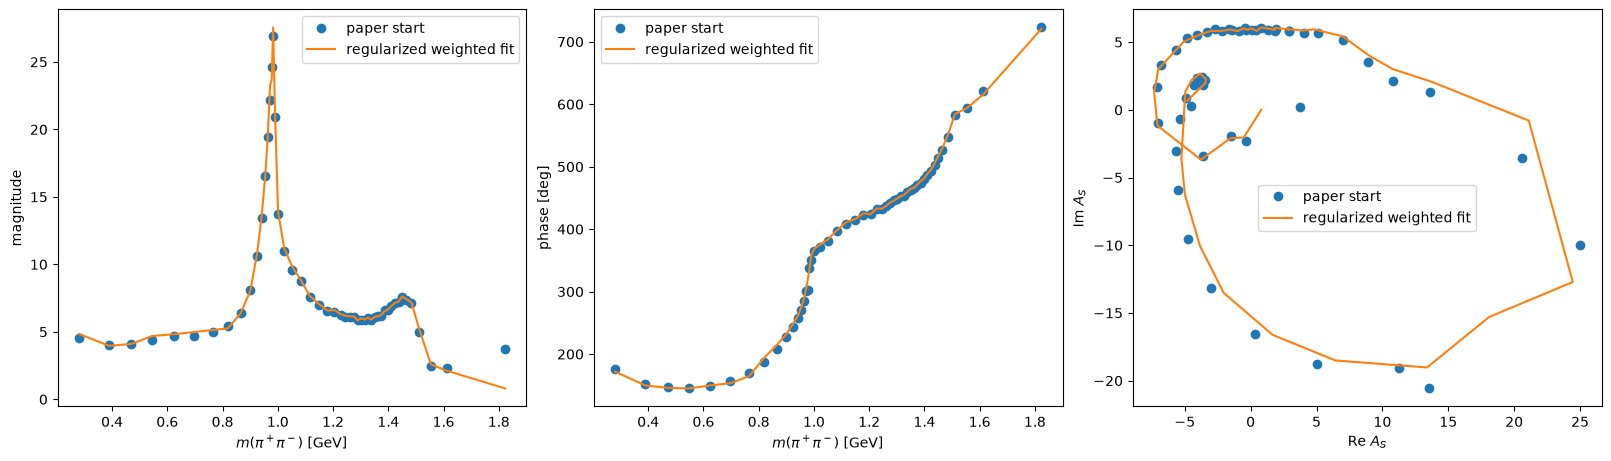

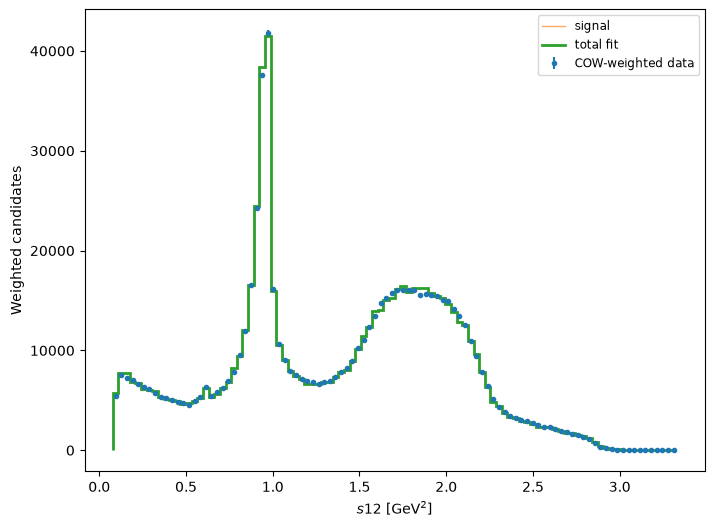

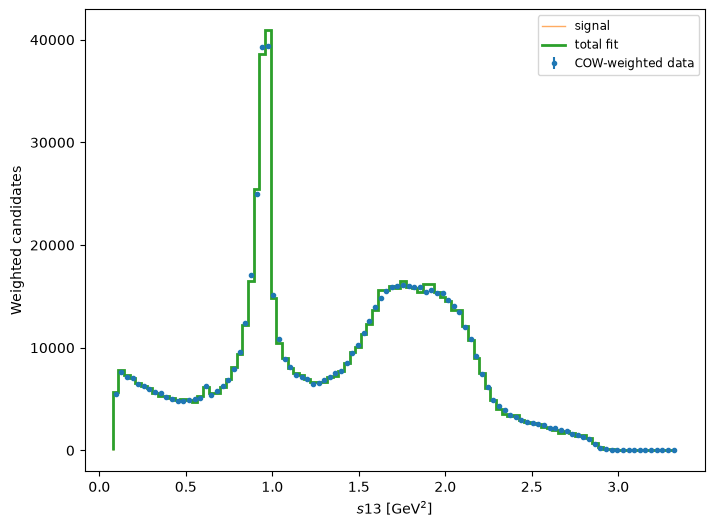

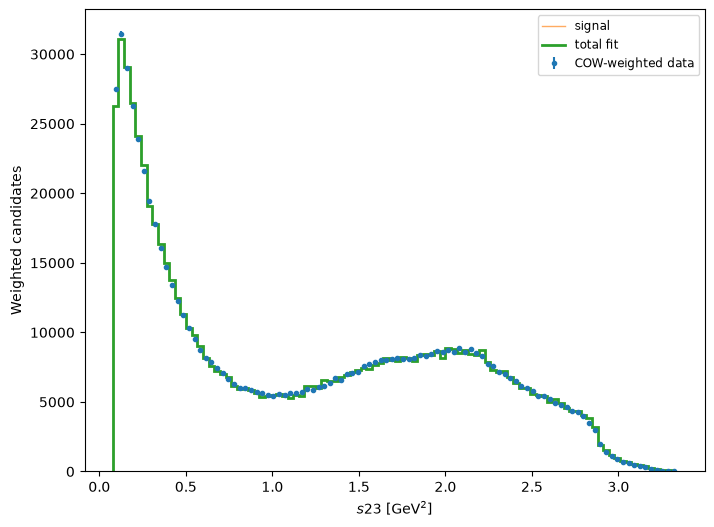

In [16]:
def plot_weighted_fit_projection(result, variable, bins=60, projection_size=500_000):
    values = session.result_values(result)
    observed = np.asarray(getattr(data, variable))
    edges = np.linspace(observed.min(), observed.max(), bins + 1)

    weighted_counts, _ = np.histogram(
        observed,
        bins=edges,
        weights=signal_weights,
    )
    weighted_variance, _ = np.histogram(
        observed,
        bins=edges,
        weights=signal_weights**2,
    )

    projection_sample = session._get_projection_sample(projection_size, TOY_SEED)
    total = np.zeros(bins, dtype=float)
    components = []
    for name, component_sample, component_weights in session._projection_components(
        values,
        projection_sample,
    ):
        component_values = np.asarray(getattr(component_sample, variable))
        counts, _ = np.histogram(
            component_values,
            bins=edges,
            weights=np.asarray(component_weights),
        )
        total += counts
        components.append((name, counts))

    scale = signal_weights.sum() / max(total.sum(), 1e-300)
    centers = 0.5 * (edges[:-1] + edges[1:])

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.errorbar(
        centers,
        weighted_counts,
        yerr=np.sqrt(weighted_variance),
        fmt='o',
        markersize=3,
        label='COW-weighted data',
    )
    for name, counts in components:
        ax.stairs(scale * counts, edges, label=name, alpha=0.65)
    ax.stairs(scale * total, edges, label='total fit', linewidth=2)
    ax.set(
        xlabel='$' + variable + '$ [GeV$^2$]',
        ylabel='Weighted candidates',
    )
    ax.legend(fontsize='small')
    plt.show()


if RUN_FIT:
    values = session.result_values(result)
    print('Weighted NLL fit:', float(weighted_nll(values)))
    session.print_fit_fractions(
        result,
        acceptance_weighted=False,
        include_interference=True,
        precision=4,
        with_errors=(barrier_covariance_reports[id(result)]['status'] == 'applied'),
    )

    fit_mag = np.array([values[f'S.mag_{i:02d}'] for i in range(50)])
    fit_phase = np.array([values[f'S.phase_{i:02d}'] for i in range(50)])
    paper_complex = QMI_MAGNITUDE_PAPER * np.exp(1j * QMI_PHASE_RAD_START)
    fit_complex = fit_mag * np.exp(1j * fit_phase)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
    axes[0].plot(QMI_KNOTS_GEV, QMI_MAGNITUDE_PAPER, 'o', label='paper start')
    axes[0].plot(QMI_KNOTS_GEV, fit_mag, '-', label='regularized weighted fit')
    axes[0].set(xlabel=r'$m(\pi^+\pi^-)$ [GeV]', ylabel='magnitude')
    axes[0].legend()

    axes[1].plot(
        QMI_KNOTS_GEV,
        np.rad2deg(QMI_PHASE_RAD_START),
        'o',
        label='paper start',
    )
    axes[1].plot(
        QMI_KNOTS_GEV,
        np.rad2deg(fit_phase),
        '-',
        label='regularized weighted fit',
    )
    axes[1].set(xlabel=r'$m(\pi^+\pi^-)$ [GeV]', ylabel='phase [deg]')
    axes[1].legend()

    axes[2].plot(
        paper_complex.real,
        paper_complex.imag,
        'o',
        label='paper start',
    )
    axes[2].plot(
        fit_complex.real,
        fit_complex.imag,
        '-',
        label='regularized weighted fit',
    )
    axes[2].set(xlabel=r'Re $A_S$', ylabel=r'Im $A_S$')
    axes[2].legend()
    plt.show()

    for variable in ('s12', 's13', 's23'):
        plot_weighted_fit_projection(result, variable, bins=100)


## 10. Optional regularization sensitivity scan

Enable `RUN_BARRIER_SCAN` in the configuration cell and rerun this cell after preparing
the objective. Every setting starts from the same immutable `dp_start` mapping; there is no
automatic choice of a best lambda/epsilon based on the smallest objective, since
different settings define different objectives. `scan_results` retains each Minuit
result and `scan_diagnostics` its unpenalized Q, penalty, convergence status and
active-event counts and covariance correction status. Compare QMI curves only among converged results. Stability
across this scan is a diagnostic, not a replacement for a bias/coverage study.


In [18]:
scan_results = {}
scan_diagnostics = []
if RUN_BARRIER_SCAN:
    print(
        'lambda  epsilon  valid       EDM              Q       penalty'
        '    active  covariance'
    )
    for strength, epsilon in BARRIER_SCAN_SETTINGS:
        objective = make_barrier_objective(strength, epsilon)
        scan_result = fit_barrier(objective, verbose=0, compute_covariance=False)
        fitted_values = session.result_values(scan_result)
        diagnostic = barrier_diagnostics(objective, fitted_values)
        diagnostic.update(
            strength=strength, epsilon=epsilon, valid=bool(scan_result.valid),
            edm=float(scan_result.fmin.edm), values=fitted_values,
            covariance_status=barrier_covariance_reports[id(scan_result)]['status'],
        )
        scan_results[(strength, epsilon)] = scan_result
        scan_diagnostics.append(diagnostic)
        print(
            f'{strength:6g} {epsilon:8g} {str(scan_result.valid):>5s} '
            f'{scan_result.fmin.edm:9.2g} {diagnostic["Q"]:14.5f} '
            f'{diagnostic["penalty"]:12.5f} {diagnostic["active_events"]:9d} '
            f'{diagnostic["covariance_status"]}'
        )

    # The final iteration's `objective` would otherwise survive as a
    # global and keep its compiled Hessian backend resident.
    del objective
    gc.collect()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
    valid_rows = [row for row in scan_diagnostics if row['valid']]
    for row in valid_rows:
        values = row['values']
        magnitude = np.array([values[f'S.mag_{i:02d}'] for i in range(50)])
        phase = np.array([values[f'S.phase_{i:02d}'] for i in range(50)])
        label = f'lambda={row["strength"]:g}, epsilon={row["epsilon"]:g}'
        axes[0].plot(QMI_KNOTS_GEV, magnitude, label=label)
        axes[1].plot(QMI_KNOTS_GEV, np.rad2deg(np.unwrap(phase)), label=label)
    axes[0].set(xlabel='m(pipi) [GeV]', ylabel='QMI magnitude')
    axes[1].set(xlabel='m(pipi) [GeV]', ylabel='QMI phase [deg]')
    if valid_rows:
        axes[0].legend(fontsize='small')
        axes[1].legend(fontsize='small')
    else:
        print('No converged scan fits: do not interpret parameter stability.')
    plt.show()
